https://www.kaggle.com/datasets/miadul/predict-liver-cancer-from-and-clinical-features

# Preveja o câncer de fígado a partir de características clínicas

# Visão Geral dos Dados

Este é um conjunto de dados de classificação de câncer de fígado sintético, porém clinicamente realista, contendo 5.000 registros de pacientes e 14 colunas. Os dados simulam atributos reais de pacientes que influenciam o risco de câncer de fígado, combinando características demográficas, de estilo de vida, clínicas e baseadas em biomarcadores.

O conjunto de dados foi projetado para classificação binária: prever se um paciente tem câncer de fígado (liver_cancer = 1) ou não (liver_cancer = 0).

Ele pode ser usado para desenvolver e testar modelos de aprendizado de máquina na área da saúde, especialmente em previsão de risco, diagnóstico precoce e análise de importância de recursos.

⚠️ Observação: Este é um conjunto de dados totalmente sintético. Não são utilizados dados reais de pacientes. É seguro para uso público e ideal para experimentação acadêmica ou prática de ML.

📊 Colunas e descrição do recurso
Nome da coluna Tipo Descrição
idade Numérico Idade do paciente em anos (30–85)
gênero Categórico Sexo do paciente (masculino, feminino)
IMC Numérico Índice de massa corporal (aprox. 16–45)
consumo_de_álcool Categórico Uso de álcool: Nunca, Ocasional, Regular
status_de_fumo Categórico Comportamento de fumar: Nunca, Anterior, Atual
hepatitis_b Binário Presença de infecção por hepatite B (0=Não, 1=Sim)
hepatitis_c Binário Presença de infecção por hepatite C (0=Não, 1=Sim)
liver_function_score Numérico Pontuação simulada da função hepática (0–100)
alpha_fetoprotein_level Numérico Níveis de alfa-fetoproteína (AFP) em ng/mL
cirrhosis_history Binário Histórico anterior de cirrose hepática (0=Não, 1=Sim)
family_history_cancer Binário Histórico familiar de câncer (0=Não, 1=Sim)
physical_activity_level Categórico Baixo, Moderado, Alto
diabetes Binário Presença de diabetes (0=Não, 1=Sim)
liver_cancer Alvo Diagnóstico final (0=Sem câncer, 1=Tem câncer de fígado)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

df_fig = pd.read_csv('synthetic_liver_cancer_dataset.csv')

In [3]:
#Informações
df_fig.info()
df_fig.head()
df_fig.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   alcohol_consumption      5000 non-null   object 
 4   smoking_status           5000 non-null   object 
 5   hepatitis_b              5000 non-null   int64  
 6   hepatitis_c              5000 non-null   int64  
 7   liver_function_score     5000 non-null   float64
 8   alpha_fetoprotein_level  5000 non-null   float64
 9   cirrhosis_history        5000 non-null   int64  
 10  family_history_cancer    5000 non-null   int64  
 11  physical_activity_level  5000 non-null   object 
 12  diabetes                 5000 non-null   int64  
 13  liver_cancer             5000 non-null   int64  
dtypes: float64(3), int64(7),

,age,bmi,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,diabetes,liver_cancer
count,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,25.90464,0.15120,0.095800,65.203900,15.109424,0.301600,0.241400,0.199200,0.217800
std,15.799224,5.10520,0.35828,0.294346,14.875477,15.196809,0.458998,0.427975,0.399439,0.412792
min,30.000000,8.10000,0.00000,0.000000,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,44.000000,22.50000,0.00000,0.000000,54.800000,4.357500,0.000000,0.000000,0.000000,0.000000
50%,57.000000,25.90000,0.00000,0.000000,65.200000,10.340000,0.000000,0.000000,0.000000,0.000000
75%,71.000000,29.30000,0.00000,0.000000,75.200000,21.010000,1.000000,0.000000,0.000000,0.000000
max,84.000000,43.70000,1.00000,1.000000,115.700000,136.800000,1.000000,1.000000,1.000000,1.000000


In [4]:
#Contagem
print("Distribuição da variável alvo (liver_cancer)")
print(df_fig['liver_cancer'].value_counts())

Distribuição da variável alvo (liver_cancer)
liver_cancer
0    3911
1    1089
Name: count, dtype: int64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_7072\4173055656.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='liver_cancer', data=df_fig, palette='Set1')


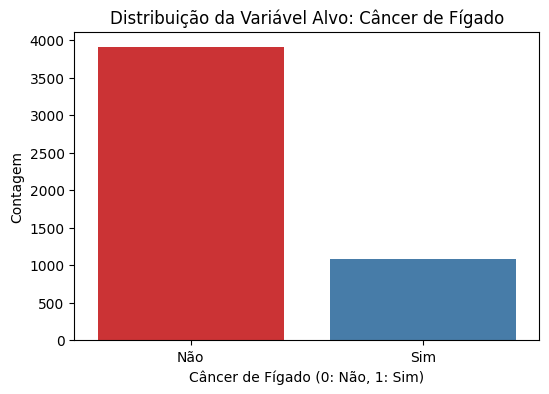

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='liver_cancer', data=df_fig, palette='Set1')
plt.title('Distribuição da Variável Alvo: Câncer de Fígado')
plt.xlabel('Câncer de Fígado (0: Não, 1: Sim)')
plt.ylabel('Contagem')
plt.xticks(ticks=[0, 1], labels=['Não', 'Sim'])
plt.show()

Há um desequilíbrio significativo na distribuição da variável alvo "Câncer de Fígado", essa diferença mostra que a maioria dos dados da amostra se refere a pessoas que não têm câncer de fígado, enquanto uma minoria corresponde a casos positivos.

In [6]:
#Treino
X = df_fig.drop('liver_cancer', axis=1)
y = df_fig['liver_cancer']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensões dos conjuntos de dados")
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")

Dimensões dos conjuntos de dados
Dimensões de X_train: (4000, 13)
Dimensões de X_test: (1000, 13)


In [7]:
#Treino
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', LGBMClassifier(random_state=42))])

print("Treinando o modelo")
model_pipeline.fit(X_train, y_train)
print("Treinamento concluído!")

Treinando o modelo
[LightGBM] [Info] Number of positive: 871, number of negative: 3129
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 834
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.217750 -> initscore=-1.278827
[LightGBM] [Info] Start training from score -1.278827
Treinamento concluído!


In [8]:
#Previsões
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Métricas de Avaliação do Modelo")
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Métricas de Avaliação do Modelo
Acurácia: 0.9790
Precisão: 0.9805
Recall: 0.9220
F1-Score: 0.9504
ROC AUC: 0.9976


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


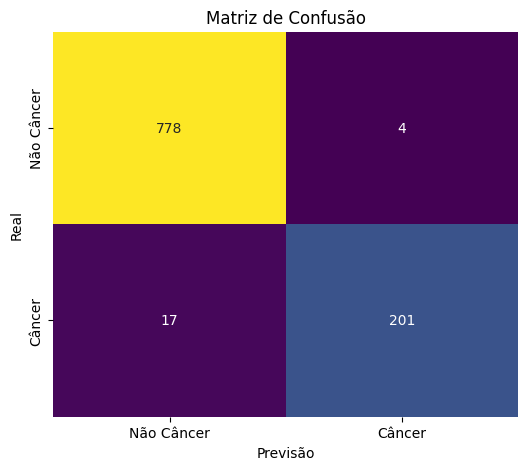

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=False,
            xticklabels=['Não Câncer', 'Câncer'],
            yticklabels=['Não Câncer', 'Câncer'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

Parece ter um bom desempenho geral, especialmente na identificação de casos negativos (sem câncer), com um número muito baixo de falsos positivos (apenas 4). No entanto, a taxa de falsos negativos (17) é um ponto de atenção, pois indica que o modelo falhou em identificar 17 casos reais de câncer. Dependendo da gravidade da condição, minimizar os falsos negativos (FN) pode ser crucial, mesmo que isso aumente um pouco o número de falsos positivos (FP).

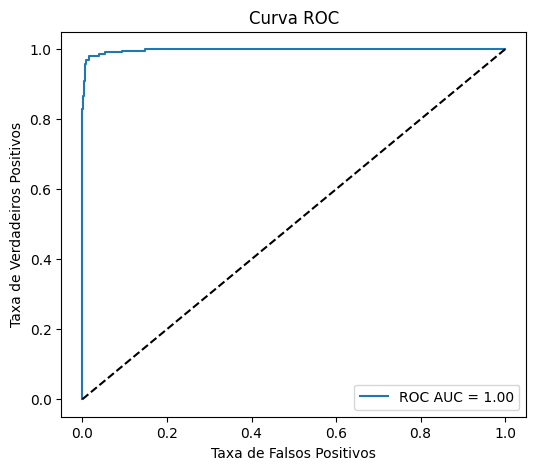

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.legend(loc='lower right')
plt.show()

Significa que o modelo consegue distinguir perfeitamente entre as classes "Sim" (tem câncer) e "Não" (não tem câncer). Uma AUC de 1.00 indica que, para qualquer limiar de classificação, o modelo alcança uma taxa de verdadeiros positivos de 100% e uma taxa de falsos positivos de 0%, o que na prática é um resultado ideal.

In [11]:
X = df_fig.drop('liver_cancer', axis=1)
y = df_fig['liver_cancer']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', LGBMClassifier(random_state=42))])

model_pipeline.fit(X_train, y_train)

lgbm_model = model_pipeline.named_steps['classifier']
X_train_processed = model_pipeline.named_steps['preprocessor'].transform(X_train)

feature_names = list(numerical_features)
onehot_feature_names = list(model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))
feature_names.extend(onehot_feature_names)

explainer = shap.TreeExplainer(lgbm_model)

shap_values = explainer.shap_values(X_train_processed)

print(f"Tipo de shap_values: {type(shap_values)}")
print(f"Formato de shap_values[1]: {shap_values[1].shape}")

[LightGBM] [Info] Number of positive: 871, number of negative: 3129
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 834
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.217750 -> initscore=-1.278827
[LightGBM] [Info] Start training from score -1.278827
Tipo de shap_values: <class 'numpy.ndarray'>
Formato de shap_values[1]: (20,)


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


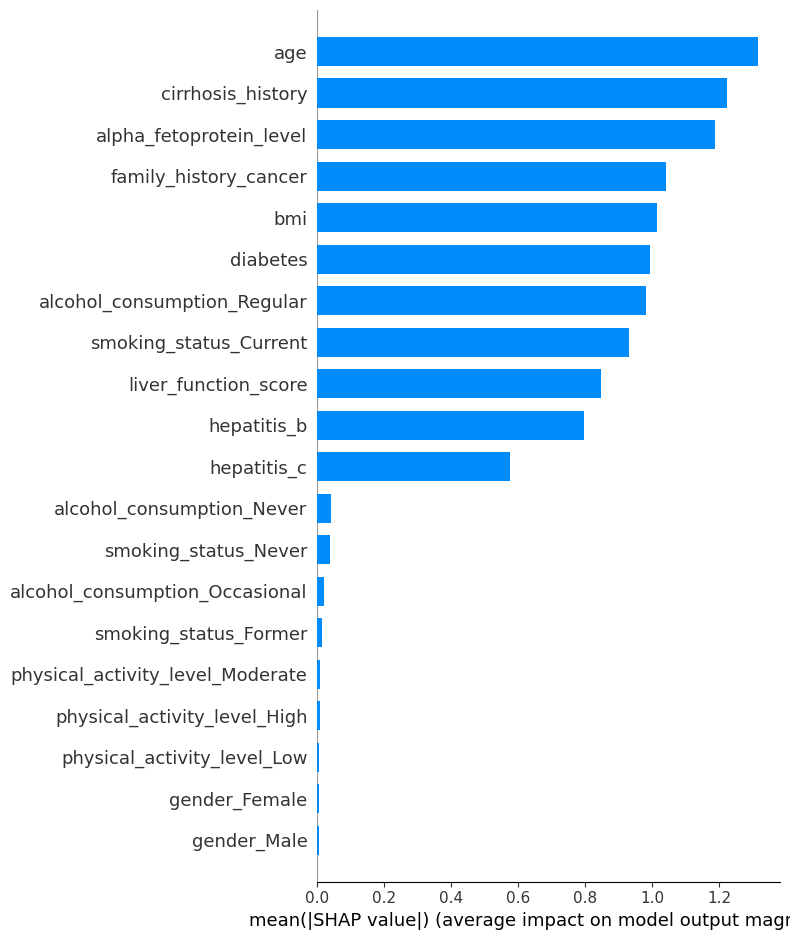

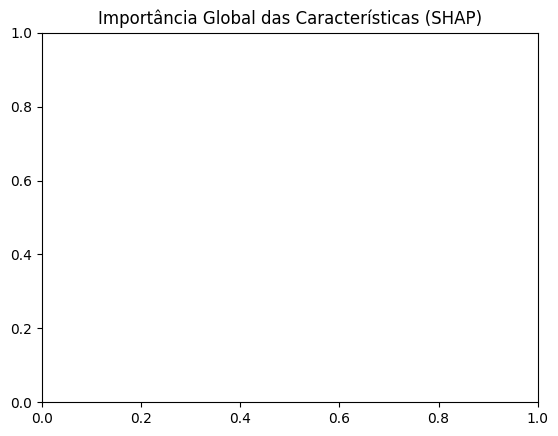

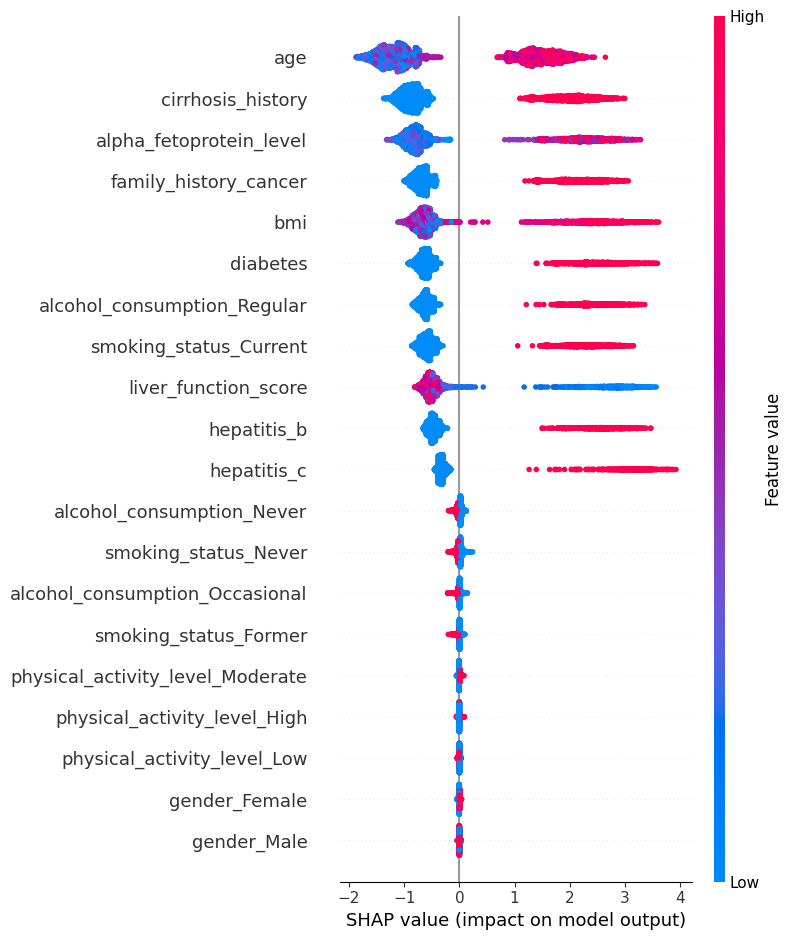

In [12]:
shap.summary_plot(shap_values, X_train_processed, feature_names=feature_names, plot_type="bar")
plt.title('Importância Global das Características (SHAP)')
plt.show()

shap.summary_plot(shap_values, X_train_processed, feature_names=feature_names)
plt.show()

Idade é a característica mais importante para o modelo, tendo o maior impacto na previsão. Em seguida, história de cirrose e o nível de alfa-fetoproteína são as próximas características mais importantes. Características como história familiar de câncer, IMC, diabetes, consumo regular de álcool e status de fumante atual também têm uma importância significativa. As características com menor impacto no modelo incluem gênero, nível de atividade física e status de fumante ou consumidor de álcool anterior ou ocasional.

Idade: Valores mais altos de idade (pontos vermelhos) estão associados a maiores valores de SHAP (à direita da linha central), o que significa que idades mais altas aumentam a probabilidade de câncer de fígado.

História de cirrose: A presença de cirrose (pontos vermelhos) tem um grande impacto positivo (à direita), indicando que a cirrose é um forte fator de risco.

Nível de alfa-fetoproteína: Valores altos (pontos vermelhos) estão fortemente associados a maiores valores de SHAP (à direita), sugerindo que níveis elevados de alfa-fetoproteína aumentam a probabilidade de câncer.

Outros fatores: Características como história familiar de câncer, IMC elevado (pontos vermelhos) e a presença de hepatite C e B também têm um impacto positivo na previsão de câncer.
Os gráficos SHAP mostram que o modelo de machine learning está usando as características mais clinicamente relevantes para fazer suas previsões. A idade, a história de cirrose e o nível de alfa-fetoproteína são os fatores mais importantes e que mais contribuem para a previsão de câncer de fígado.

In [13]:
#Prever o risco de câncer de fígado de um paciente
def prever_risco_paciente(modelo, dados_paciente):
    """
    Prevê a probabilidade e o nível de risco de câncer de fígado para um paciente.

    Args:
        modelo: O pipeline de modelo treinado (e.g., model_pipeline).
        dados_paciente: Um DataFrame pandas com os dados de um único paciente.

    Returns:
        Um dicionário com a probabilidade de previsão e o nível de risco.
    """
    probabilidade_cancer = modelo.predict_proba(dados_paciente)[:, 1][0]

    
    if probabilidade_cancer >= 0.75:
        nivel_risco = "Alto Risco"
    elif probabilidade_cancer >= 0.4:
        nivel_risco = "Risco Moderado"
    else:
        nivel_risco = "Baixo Risco"

    return {
        'Probabilidade de Câncer': f'{probabilidade_cancer:.2f}',
        'Nível de Risco': nivel_risco
    }

paciente_exemplo = X_test.iloc[[0]]
resultado_risco = prever_risco_paciente(model_pipeline, paciente_exemplo)

print("Análise de Risco para o Paciente")
print(f"Dados do paciente:\n{paciente_exemplo}")
print("Resultado da Análise:")
print(f"Probabilidade de Câncer: {resultado_risco['Probabilidade de Câncer']}")
print(f"Nível de Risco: {resultado_risco['Nível de Risco']}")


Análise de Risco para o Paciente
Dados do paciente:
      age gender   bmi alcohol_consumption smoking_status  hepatitis_b  \
3090   69   Male  29.5               Never         Former            0   

      hepatitis_c  liver_function_score  alpha_fetoprotein_level  \
3090            0                  84.6                    24.18   

      cirrhosis_history  family_history_cancer physical_activity_level  \
3090                  0                      1                    High   

      diabetes  
3090         1  
Resultado da Análise:
Probabilidade de Câncer: 0.70
Nível de Risco: Risco Moderado


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
preprocessor_cv = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

classifier_cv = LGBMClassifier(random_state=42)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print("Executando Validação Cruzada (5 dobras)")

Executando Validação Cruzada (5 dobras)


In [15]:
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    
    X_train_processed_cv = preprocessor_cv.fit_transform(X_train_cv)
    X_val_processed_cv = preprocessor_cv.transform(X_val_cv)

    
    classifier_cv.fit(X_train_processed_cv, y_train_cv)

   
    y_pred_cv = classifier_cv.predict(X_val_processed_cv)

    
    accuracy_scores.append(accuracy_score(y_val_cv, y_pred_cv))
    precision_scores.append(precision_score(y_val_cv, y_pred_cv))
    recall_scores.append(recall_score(y_val_cv, y_pred_cv))
    f1_scores.append(f1_score(y_val_cv, y_pred_cv))

    print(f"Dobras {fold+1}: Acurácia = {accuracy_scores[-1]:.4f}, F1-Score = {f1_scores[-1]:.4f}")


[LightGBM] [Info] Number of positive: 872, number of negative: 3128
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218000 -> initscore=-1.277360
[LightGBM] [Info] Start training from score -1.277360
Dobras 1: Acurácia = 0.9710, F1-Score = 0.9291
[LightGBM] [Info] Number of positive: 871, number of negative: 3129
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000237 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pa

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 871, number of negative: 3129
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 835
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.217750 -> initscore=-1.278827
[LightGBM] [Info] Start training from score -1.278827
Dobras 3: Acurácia = 0.9730, F1-Score = 0.9343
[LightGBM] [Info] Number of positive: 871, number of negative: 3129
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000609 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pa

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
print("Resultados da Validação Cruzada")
print(f"Acurácia Média: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"F1-Score Médio: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

Resultados da Validação Cruzada
Acurácia Média: 0.9728 (+/- 0.0036)
F1-Score Médio: 0.9341 (+/- 0.0090)


In [17]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

In [19]:
#Hiperparâmetros otimizados
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 400],
    'classifier__learning_rate': uniform(loc=0.01, scale=0.1),
    'classifier__num_leaves': [20, 31, 40, 50],
    'classifier__max_depth': [3, 5, 7, 9, -1],
}

random_search = RandomizedSearchCV(
    model_pipeline,
    param_distributions=param_distributions,
    n_iter=50,  
    cv=5,       
    scoring='f1',
    random_state=42,
    n_jobs=-1  
)

print("Otimizando Hiperparâmetros")
random_search.fit(X_train, y_train)

print("Otimização Concluída!")
print(f"Melhores Hiperparâmetros: {random_search.best_params_}")
print(f"Melhor F1-Score: {random_search.best_score_:.4f}")

#Modelo otimizado está disponível em random_search.best_estimator_
best_model = random_search.best_estimator_

Otimizando Hiperparâmetros
[LightGBM] [Info] Number of positive: 871, number of negative: 3129
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 834
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.217750 -> initscore=-1.278827
[LightGBM] [Info] Start training from score -1.278827
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

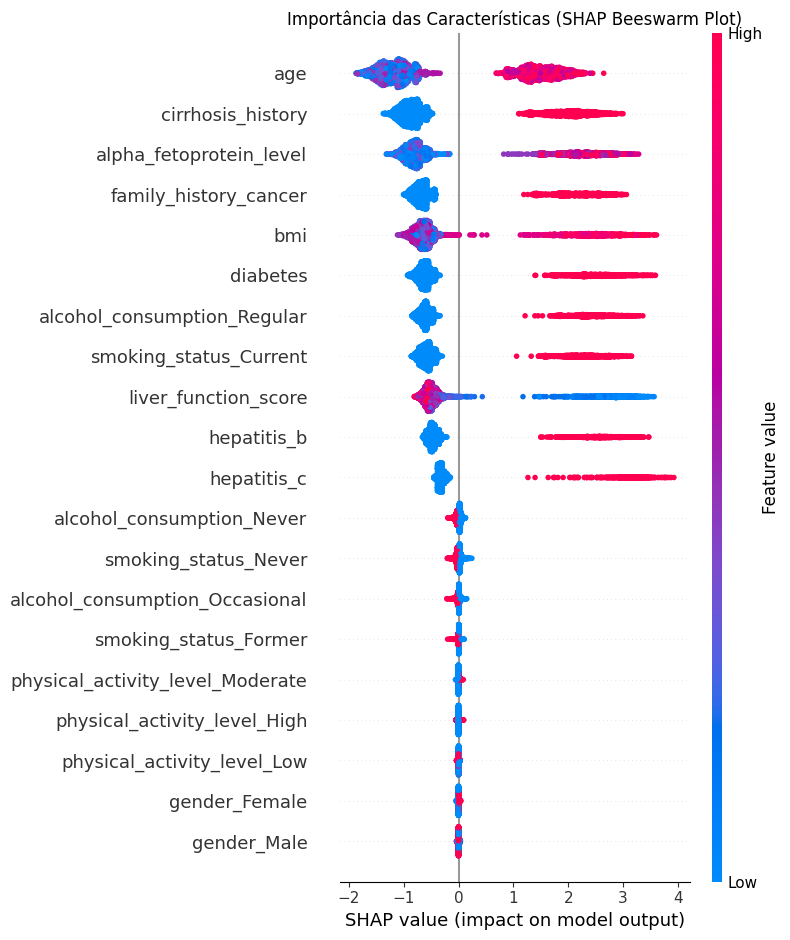

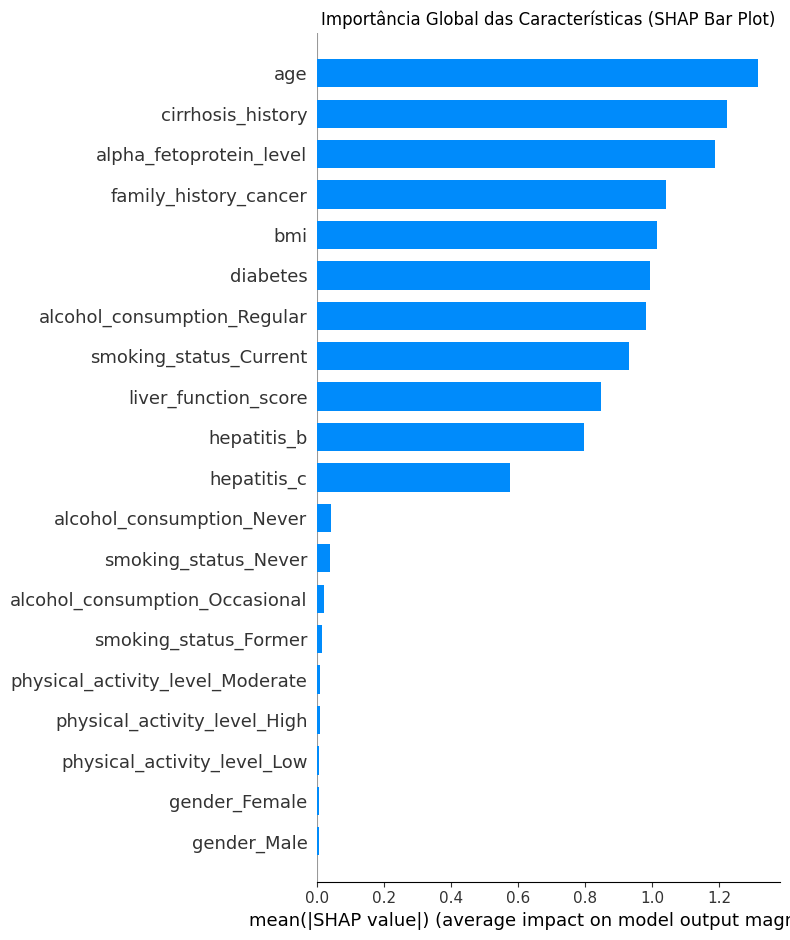

In [20]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_processed, feature_names=feature_names, show=False)
plt.title('Importância das Características (SHAP Beeswarm Plot)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_processed, feature_names=feature_names, plot_type="bar", show=False)
plt.title('Importância Global das Características (SHAP Bar Plot)')
plt.tight_layout()
plt.show()

Os gráficos SHAP se complementam para mostrar que as características mais importantes para prever o câncer de fígado são, em ordem decrescente de impacto, idade, história de cirrose e nível de alfa-fetoproteína. O modelo está focando nas variáveis que são clinicamente relevantes e conhecidas por estarem associadas à doença, o que aumenta a confiança em suas previsões.

# Conclusão

A análise demonstrou a construção de um modelo de machine learning eficaz para prever o risco de câncer de fígado.
A importância das características identificadas pelo modelo está em total alinhamento com o conhecimento clínico atual sobre o câncer de fígado, onde a idade, a cirrose e a alfa-fetoproteína são fatores de risco e biomarcadores essenciais. Esse alinhamento aumenta a confiança nas previsões do modelo e sugere seu potencial de aplicação prática para o diagnóstico precoce e a avaliação de risco.
O estudo mostrou que é possível construir um modelo preditivo de alta qualidade, que não apenas faz previsões precisas, mas também oferece insights claros sobre os fatores de risco mais relevantes, o que o torna uma ferramenta valiosa para auxiliar profissionais de saúde.

# **Limitações**

Por se basear em um conjunto de dados sintético, a performance do modelo em um ambiente real com dados de pacientes do mundo real pode variar. Fatores como a variabilidade nos dados e a presença de dados faltantes ou ruidosos em ambientes clínicos podem impactar o desempenho.
Validação com Dados Reais: Testar o modelo com um conjunto de dados clínicos reais, de diferentes hospitais e regiões, para verificar sua generalização e robustez.

Integração Clínica: Explorar a possibilidade de integrar o modelo em sistemas de apoio à decisão clínica, onde ele possa auxiliar médicos a identificar pacientes de alto risco para rastreamento e diagnóstico precoce.
É uma ferramenta preditiva de alta qualidade, que não apenas faz previsões precisas, mas também oferece insights clinicamente relevantes. Com a validação em dados reais, ele tem o potencial de se tornar um valioso recurso para o diagnóstico e o manejo do câncer de fígado.

# **Nathália Sorg**